In [1]:
import tensorflow as tf

In [2]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

X_train.shape
X_test.shape
y_train.shape
y_test.shape

(60000, 28, 28)

(10000, 28, 28)

(60000,)

(10000,)

In [3]:
len(X_train)
X_train[0].shape
X_train[0][0]
# There are 60,000 images where each image is of size 28 X 28, It is a grayscale image because there are two channels.

60000

(28, 28)

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0], dtype=uint8)

In [4]:
import matplotlib.pyplot as plt
import numpy as np

Text(0.5, 0.98, 'One sample per image per digit class')

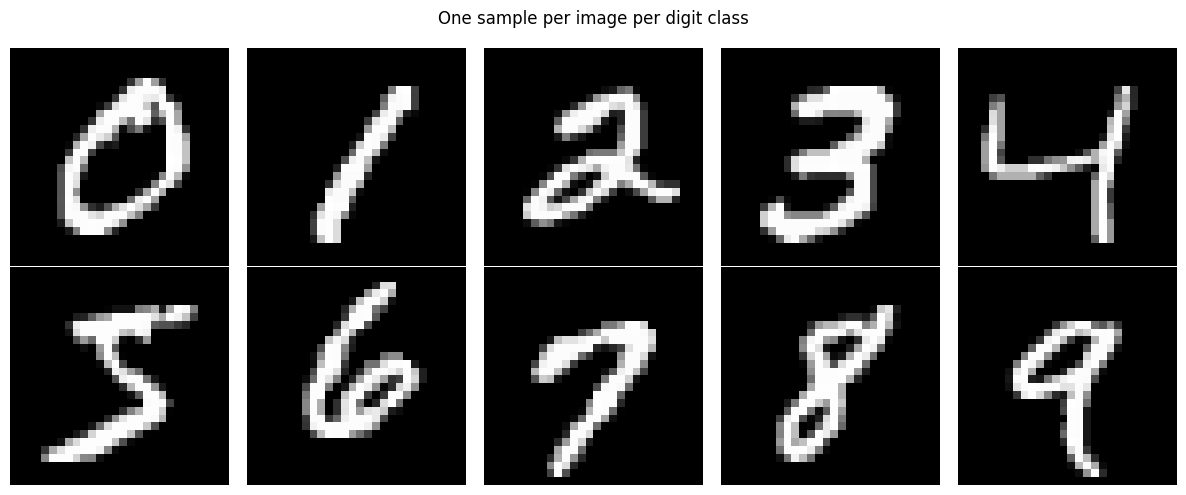

In [5]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle('One sample per image per digit class')

for digit in range(10):
  idx = np.where(y_train == digit)[0][0]
  row, col = divmod(digit, 5)
  _ = axes[row, col].imshow(X_train[idx], cmap='gray')
  _ = axes[row, col].axis('off')

plt.tight_layout()

In [6]:
import collections

train_counts = collections.Counter(y_train.tolist())
test_counts = collections.Counter(y_test.tolist())

print(f'num train test')
for i in range(10):
  print(f'{i}   {train_counts[i]}   {test_counts[i]}')

num train test
0   5923   980
1   6742   1135
2   5958   1032
3   6131   1010
4   5842   982
5   5421   892
6   5918   958
7   6265   1028
8   5851   974
9   5949   1009


In [7]:
28*28
# X_train[0]

784

## Preprocessing step

In [8]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [9]:
X_train_flat = X_train.reshape(60000, 784)
X_test_flat = X_test.reshape(10000, 784)

X_train_flat.shape
X_test_flat.shape

(60000, 784)

(10000, 784)

In [12]:
print("Before flattening :", X_train.shape)
print("After flattening  :", X_train_flat.shape)
print(f"Pixel value range: min: {X_train_flat.min()} max: {X_train_flat.max()}")

Before flattening : (60000, 28, 28)
After flattening  : (60000, 784)
Pixel value range: min: 0.0 max: 1.0


In [13]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(784,)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(10, activation='softmax'),
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)